# Amazon-Style E-Commerce Sales Analytics

## 05 — Customer Analytics & RFM Segmentation

### Objective

The objective of this notebook is to analyze customer purchasing behavior and segment customers according to purchase recency, purchase frequency, and monetary value.

### Key Business Questions

1. How many unique customers are present?
2. How much revenue does the average customer generate?
3. What percentage of customers are repeat customers?
4. How concentrated is revenue among customers?
5. Who are the highest-value customers?
6. Which customers purchase most frequently?
7. Which customers have not purchased recently?
8. Which customer segments generate the most revenue?
9. Which customer segments contain the most customers?
10. How does customer behavior differ across product categories?

### RFM Framework

- Recency: Number of days since the customer's most recent order.
- Frequency: Number of unique orders placed by the customer.
- Monetary: Total order value generated by the customer.

The resulting RFM segments are used to identify different customer groups for business analysis.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
file_path = "C:/Users/Hp/OneDrive/Desktop/Projects/Amazon E-Commerce Sales Performance & Customer Analytics/Data/Amazon_Cleaned.csv"

df = pd.read_csv(file_path)

df["OrderDate"] = pd.to_datetime(df["OrderDate"])

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (100000, 25)


## 1. Customer Overview

The customer base is examined to understand its size and the number of orders and products associated with each customer.

In [3]:
total_customers = df["CustomerID"].nunique()
total_orders = df["OrderID"].nunique()

print(f"Unique Customers: {total_customers:,}")
print(f"Unique Orders   : {total_orders:,}")

Unique Customers: 43,233
Unique Orders   : 100,000


In [4]:
orders_per_customer = (
    df.groupby("CustomerID")["OrderID"]
      .nunique()
      .sort_values(ascending=False)
)

orders_per_customer.describe()

count    43233.000000
mean         2.313048
std          1.257115
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         10.000000
Name: OrderID, dtype: float64

In [5]:
customer_order_frequency = (
    orders_per_customer
    .value_counts()
    .sort_index()
    .reset_index()
)

customer_order_frequency.columns = [
    "Number_of_Orders",
    "Number_of_Customers"
]

customer_order_frequency

,Number_of_Orders,Number_of_Customers
0,1,13532
1,2,13504
2,3,8994
3,4,4635
4,5,1736
5,6,628
6,7,159
7,8,30
8,9,13
9,10,2


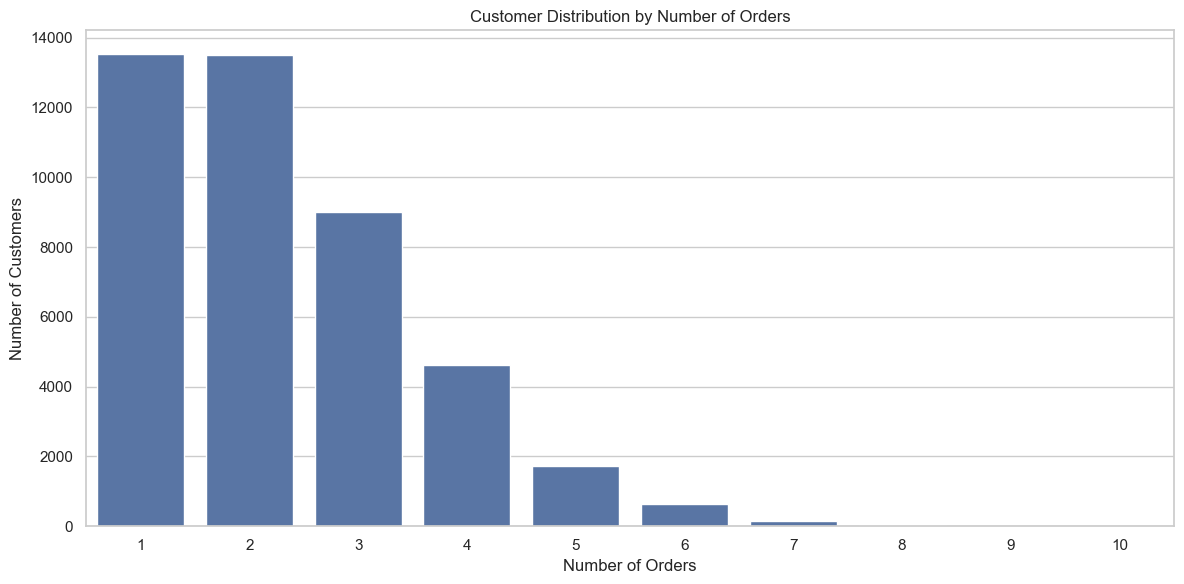

In [6]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=customer_order_frequency.head(20),
    x="Number_of_Orders",
    y="Number_of_Customers"
)

plt.title("Customer Distribution by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

## 2. Customer Revenue Analysis

Customer-level revenue is calculated to identify how much sales value each customer contributes to the business.

In [7]:
customer_summary = (
    df.groupby("CustomerID")
      .agg(
          Orders=("OrderID", "nunique"),
          Revenue=("TotalAmount", "sum"),
          Units=("Quantity", "sum"),
          Average_Order_Value=("TotalAmount", "mean"),
          First_Order_Date=("OrderDate", "min"),
          Last_Order_Date=("OrderDate", "max")
      )
      .reset_index()
)

customer_summary.head()

,CustomerID,Orders,Revenue,Units,Average_Order_Value,First_Order_Date,Last_Order_Date
0,CUST000001,1,446.48,1,446.480000,2024-07-26,2024-07-26
1,CUST000002,3,1389.93,9,463.310000,2020-07-02,2022-02-01
2,CUST000003,1,1116.91,5,1116.910000,2020-12-28,2020-12-28
3,CUST000004,3,2660.06,7,886.686667,2023-06-08,2024-06-17
4,CUST000005,1,1089.56,4,1089.560000,2023-03-31,2023-03-31


In [8]:
customer_summary[
    [
        "Orders",
        "Revenue",
        "Units",
        "Average_Order_Value"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Orders,43233.0,2.313048,1.257115,1.00,1.00,2.000000,3.000000,10.00
Revenue,43233.0,2123.971224,1594.379364,6.19,876.19,1805.410000,2992.430000,15215.79
Units,43233.0,6.942382,4.347894,1.00,4.00,6.000000,9.000000,35.00
Average_Order_Value,43233.0,918.459175,551.590687,6.19,508.94,837.093333,1226.146667,3484.44


## 3. Customer Revenue Distribution

The distribution of customer-level spending is analyzed to understand whether spending is evenly distributed or concentrated among a smaller group of customers.

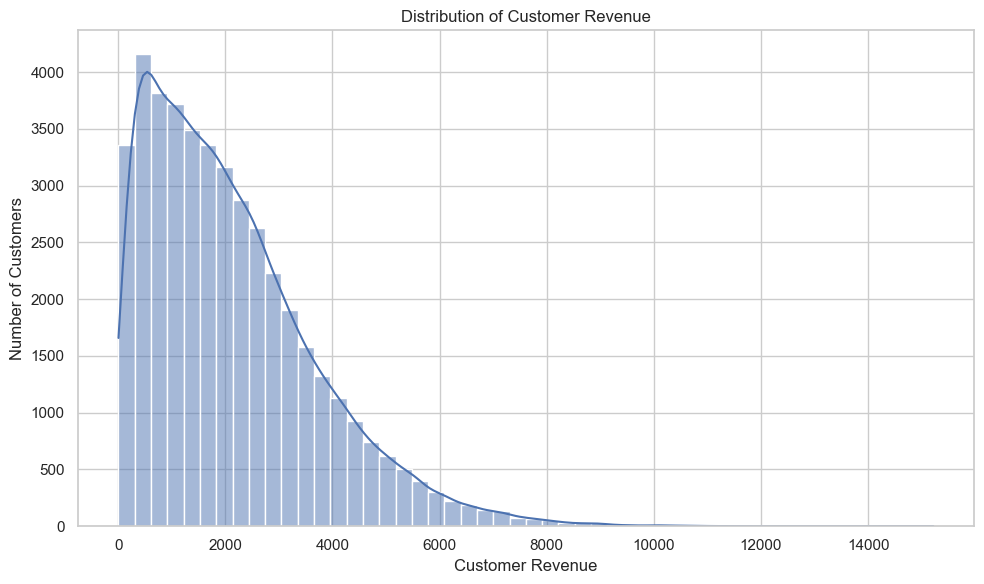

In [9]:
plt.figure(figsize=(10, 6))

sns.histplot(
    customer_summary["Revenue"],
    bins=50,
    kde=True
)

plt.title("Distribution of Customer Revenue")
plt.xlabel("Customer Revenue")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

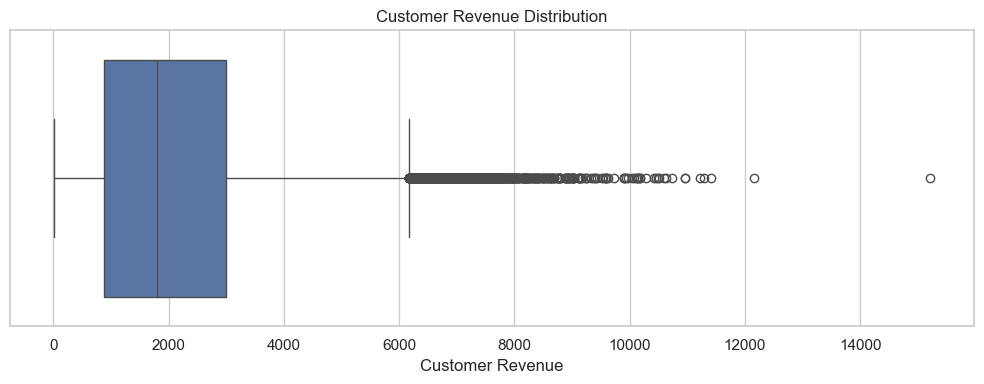

In [10]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=customer_summary["Revenue"]
)

plt.title("Customer Revenue Distribution")
plt.xlabel("Customer Revenue")

plt.tight_layout()
plt.show()

## 4. Repeat Customer Analysis

Customers are classified as one-time or repeat customers based on the number of unique orders placed.

A repeat customer is defined as a customer with more than one unique order.

In [11]:
customer_summary["Customer_Type"] = np.where(
    customer_summary["Orders"] > 1,
    "Repeat Customer",
    "One-Time Customer"
)

customer_type_summary = (
    customer_summary["Customer_Type"]
    .value_counts()
    .reset_index()
)

customer_type_summary.columns = [
    "Customer_Type",
    "Customers"
]

customer_type_summary["Percentage"] = (
    customer_type_summary["Customers"] /
    customer_type_summary["Customers"].sum()
    * 100
)

customer_type_summary

,Customer_Type,Customers,Percentage
0,Repeat Customer,29701,68.699836
1,One-Time Customer,13532,31.300164


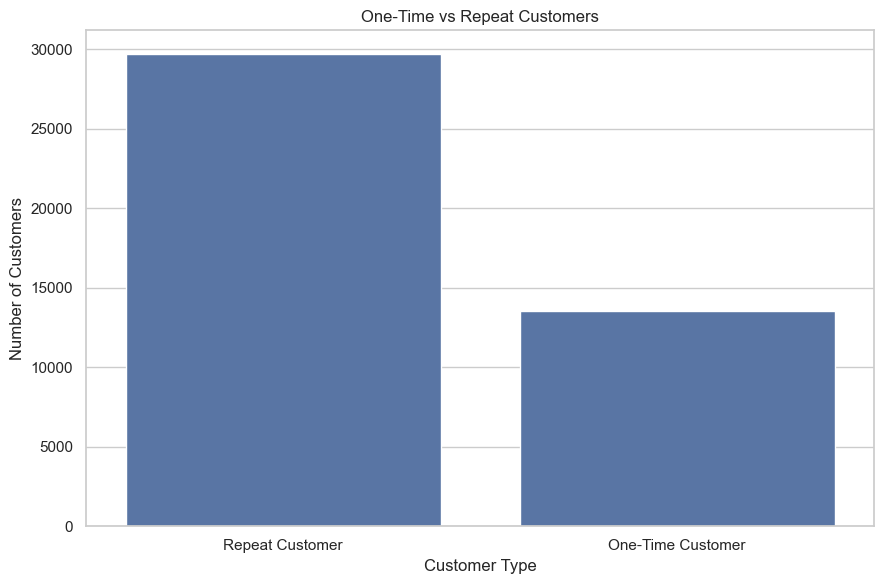

In [12]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=customer_type_summary,
    x="Customer_Type",
    y="Customers"
)

plt.title("One-Time vs Repeat Customers")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [13]:
customer_type_revenue = (
    customer_summary.groupby("Customer_Type")
    .agg(
        Customers=("CustomerID", "count"),
        Revenue=("Revenue", "sum"),
        Orders=("Orders", "sum")
    )
    .reset_index()
)

customer_type_revenue["Revenue_Share_%"] = (
    customer_type_revenue["Revenue"] /
    customer_type_revenue["Revenue"].sum()
    * 100
)

customer_type_revenue

,Customer_Type,Customers,Revenue,Orders,Revenue_Share_%
0,One-Time Customer,13532,12458289.92,13532,13.567331
1,Repeat Customer,29701,79367358.00,86468,86.432669


## 5. Customer Value Comparison

Average customer revenue and Average Order Value are compared between one-time and repeat customers.

In [14]:
customer_type_value = (
    customer_summary.groupby("Customer_Type")
    .agg(
        Average_Customer_Revenue=("Revenue", "mean"),
        Median_Customer_Revenue=("Revenue", "median"),
        Average_Orders=("Orders", "mean"),
        Average_AOV=("Average_Order_Value", "mean")
    )
    .reset_index()
)

customer_type_value

,Customer_Type,Average_Customer_Revenue,Median_Customer_Revenue,Average_Orders,Average_AOV
0,One-Time Customer,920.653999,710.755,1.000000,920.653999
1,Repeat Customer,2672.211643,2417.960,2.911282,917.459197


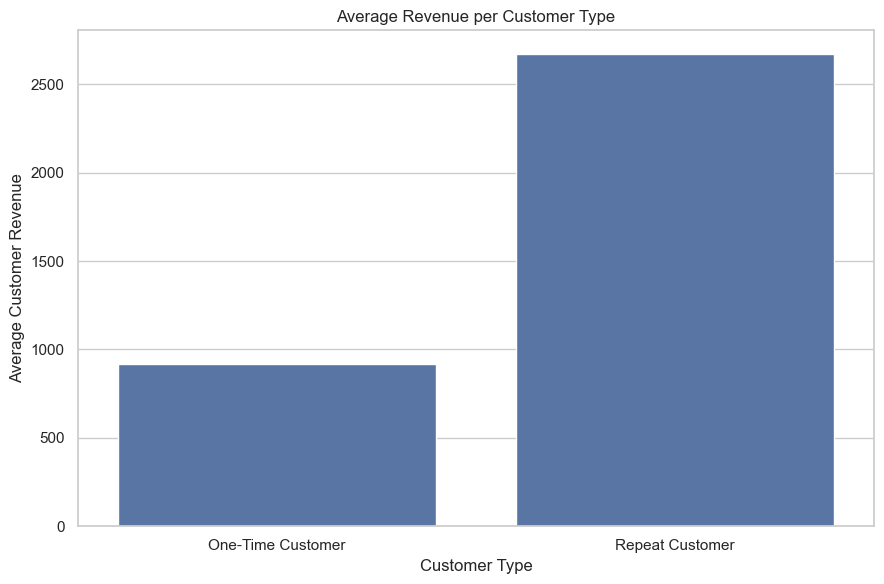

In [15]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=customer_type_value,
    x="Customer_Type",
    y="Average_Customer_Revenue"
)

plt.title("Average Revenue per Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Average Customer Revenue")

plt.tight_layout()
plt.show()

## 6. Customer Revenue Concentration

Customers are ranked by total revenue and cumulative revenue contribution is calculated to determine the concentration of sales among the customer base.

In [16]:
customer_concentration = (
    customer_summary[
        [
            "CustomerID",
            "Revenue"
        ]
    ]
    .sort_values(
        "Revenue",
        ascending=False
    )
    .copy()
)

customer_concentration["Cumulative_Revenue"] = (
    customer_concentration["Revenue"].cumsum()
)

customer_concentration["Cumulative_Revenue_Share_%"] = (
    customer_concentration["Cumulative_Revenue"] /
    customer_concentration["Revenue"].sum()
    * 100
)

customer_concentration["Customer_Rank"] = (
    range(1, len(customer_concentration) + 1)
)

customer_concentration["Customer_Share_%"] = (
    customer_concentration["Customer_Rank"] /
    len(customer_concentration)
    * 100
)

customer_concentration.head(10)

,CustomerID,Revenue,Cumulative_Revenue,Cumulative_Revenue_Share_%,Customer_Rank,Customer_Share_%
20573,CUST023748,15215.79,15215.79,0.016570,1,0.002313
8298,CUST009614,12160.96,27376.75,0.029814,2,0.004626
29589,CUST034178,11418.88,38795.63,0.042249,3,0.006939
981,CUST001153,11282.96,50078.59,0.054537,4,0.009252
4215,CUST004883,11214.44,61293.03,0.066749,5,0.011565
680,CUST000787,10962.32,72255.35,0.078688,6,0.013878
13544,CUST015677,10956.10,83211.45,0.090619,7,0.016191
36956,CUST042689,10726.80,93938.25,0.102301,8,0.018504
13164,CUST015231,10638.79,104577.04,0.113887,9,0.020817
28815,CUST033270,10593.41,115170.45,0.125423,10,0.023130


In [17]:
top_10_customer_share = (
    customer_concentration.head(10)["Revenue"].sum()
    /
    customer_concentration["Revenue"].sum()
    * 100
)

print(
    f"Top 10 customers contribute "
    f"{top_10_customer_share:.2f}% "
    f"of total customer revenue."
)

Top 10 customers contribute 0.13% of total customer revenue.


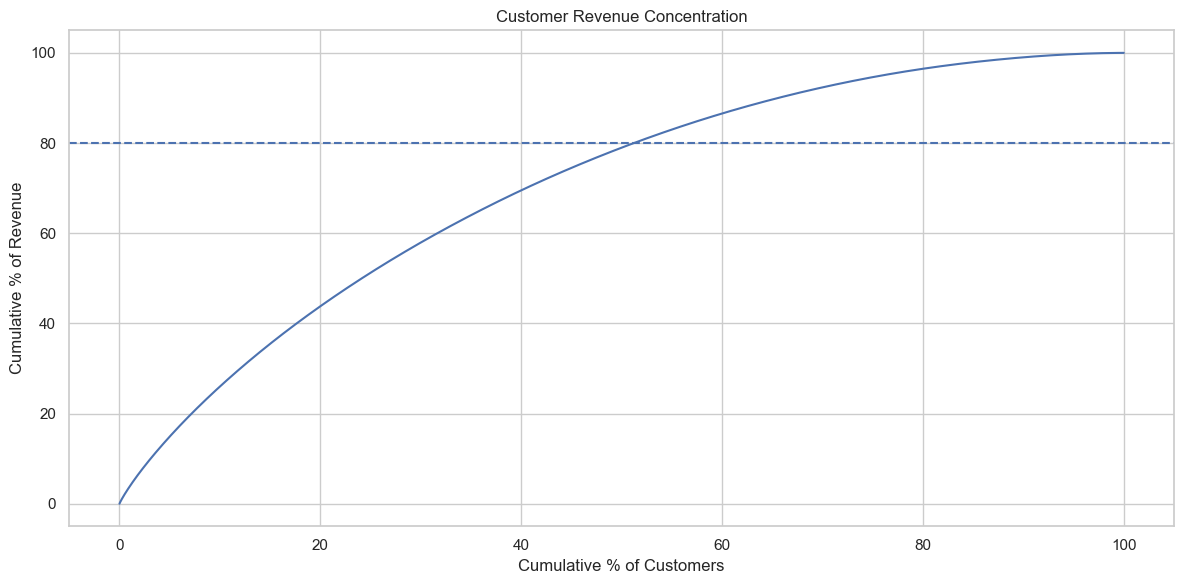

In [18]:
plt.figure(figsize=(12, 6))

plt.plot(
    customer_concentration["Customer_Share_%"],
    customer_concentration["Cumulative_Revenue_Share_%"]
)

plt.axhline(
    80,
    linestyle="--"
)

plt.title("Customer Revenue Concentration")
plt.xlabel("Cumulative % of Customers")
plt.ylabel("Cumulative % of Revenue")

plt.tight_layout()
plt.show()

## 7. RFM Analysis

RFM analysis evaluates customers using three dimensions:

### Recency
How recently the customer placed an order.

### Frequency
How frequently the customer placed orders.

### Monetary
How much total order value the customer generated.

Recency is calculated relative to the latest order date available in the dataset.

In [19]:
analysis_date = df["OrderDate"].max()

print("Analysis Date:", analysis_date)

Analysis Date: 2024-12-29 00:00:00


In [20]:
rfm = (
    df.groupby("CustomerID")
      .agg(
          Last_Order_Date=("OrderDate", "max"),
          Frequency=("OrderID", "nunique"),
          Monetary=("TotalAmount", "sum")
      )
      .reset_index()
)

rfm["Recency"] = (
    analysis_date - rfm["Last_Order_Date"]
).dt.days

rfm = rfm[
    [
        "CustomerID",
        "Recency",
        "Frequency",
        "Monetary",
        "Last_Order_Date"
    ]
]

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Last_Order_Date
0,CUST000001,156,1,446.48,2024-07-26
1,CUST000002,1062,3,1389.93,2022-02-01
2,CUST000003,1462,1,1116.91,2020-12-28
3,CUST000004,195,3,2660.06,2024-06-17
4,CUST000005,639,1,1089.56,2023-03-31


In [21]:
rfm[
    [
        "Recency",
        "Frequency",
        "Monetary"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,43233.0,627.165499,478.122067,0.00,224.00,518.00,953.00,1824.00
Frequency,43233.0,2.313048,1.257115,1.00,1.00,2.00,3.00,10.00
Monetary,43233.0,2123.971224,1594.379364,6.19,876.19,1805.41,2992.43,15215.79


## 8. RFM Scoring

Customers are assigned scores from 1 to 5 for Recency, Frequency, and Monetary value.

For Recency, a lower number of days since purchase receives a higher score.

For Frequency and Monetary value, higher values receive higher scores.

In [22]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    q=5,
    labels=[5, 4, 3, 2, 1],
    duplicates="drop"
)

In [23]:
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

In [24]:
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    q=5,
    labels=[1, 2, 3, 4, 5],
    duplicates="drop"
)

In [25]:
rfm["R_Score"] = rfm["R_Score"].astype(int)
rfm["F_Score"] = rfm["F_Score"].astype(int)
rfm["M_Score"] = rfm["M_Score"].astype(int)

In [26]:
rfm["RFM_Score"] = (
    rfm["R_Score"] +
    rfm["F_Score"] +
    rfm["M_Score"]
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Last_Order_Date,R_Score,F_Score,M_Score,RFM_Score
0,CUST000001,156,1,446.48,2024-07-26,5,1,1,7
1,CUST000002,1062,3,1389.93,2022-02-01,2,4,2,8
2,CUST000003,1462,1,1116.91,2020-12-28,1,1,2,4
3,CUST000004,195,3,2660.06,2024-06-17,4,4,4,12
4,CUST000005,639,1,1089.56,2023-03-31,3,1,2,6


## 9. Customer Segmentation

Customers are assigned business-oriented segments based on their RFM scores.

The segments are analytical classifications and should not be interpreted as definitive customer personas.

In [27]:
def rfm_segment(row):
    
    r = row["R_Score"]
    f = row["F_Score"]
    m = row["M_Score"]
    
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    
    elif r >= 3 and f >= 4 and m >= 3:
        return "Loyal Customers"
    
    elif r >= 4 and f >= 2 and m >= 2:
        return "Potential Loyalists"
    
    elif r >= 4 and f == 1:
        return "Recent Customers"
    
    elif r <= 2 and f >= 4 and m >= 3:
        return "At Risk High Value"
    
    elif r <= 2 and f >= 3:
        return "At Risk"
    
    elif r <= 2 and f <= 2 and m >= 3:
        return "Previously High Value"
    
    else:
        return "Needs Attention"

In [28]:
rfm["Customer_Segment"] = rfm.apply(
    rfm_segment,
    axis=1
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Last_Order_Date,R_Score,F_Score,M_Score,RFM_Score,Customer_Segment
0,CUST000001,156,1,446.48,2024-07-26,5,1,1,7,Recent Customers
1,CUST000002,1062,3,1389.93,2022-02-01,2,4,2,8,At Risk
2,CUST000003,1462,1,1116.91,2020-12-28,1,1,2,4,Needs Attention
3,CUST000004,195,3,2660.06,2024-06-17,4,4,4,12,Champions
4,CUST000005,639,1,1089.56,2023-03-31,3,1,2,6,Needs Attention


## 10. Customer Segment Distribution

The size of each customer segment is analyzed to understand the composition of the customer base.

In [29]:
segment_distribution = (
    rfm["Customer_Segment"]
    .value_counts()
    .reset_index()
)

segment_distribution.columns = [
    "Customer_Segment",
    "Customers"
]

segment_distribution["Customer_Share_%"] = (
    segment_distribution["Customers"] /
    segment_distribution["Customers"].sum()
    * 100
)

segment_distribution

,Customer_Segment,Customers,Customer_Share_%
0,Needs Attention,13579,31.408877
1,Champions,7131,16.494345
2,Potential Loyalists,5534,12.800407
3,Loyal Customers,5044,11.667014
4,At Risk,4055,9.379409
5,At Risk High Value,3148,7.281475
6,Previously High Value,2953,6.830430
7,Recent Customers,1789,4.138043


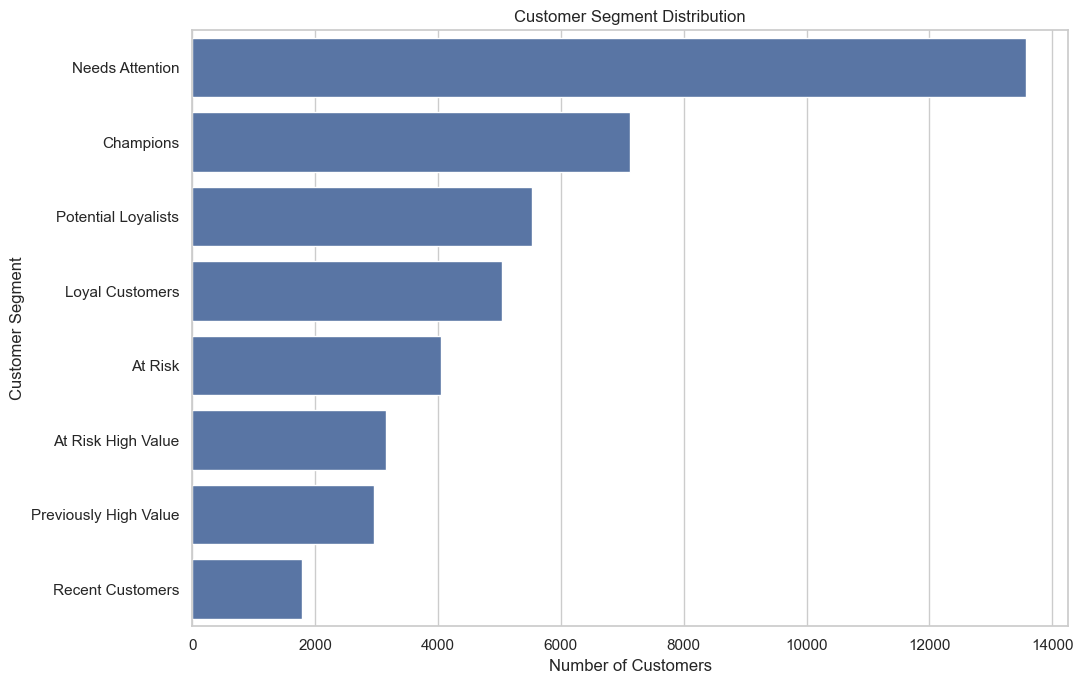

In [30]:
plt.figure(figsize=(11, 7))

sns.barplot(
    data=segment_distribution,
    x="Customers",
    y="Customer_Segment"
)

plt.title("Customer Segment Distribution")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

In [31]:
segment_performance = (
    rfm.groupby("Customer_Segment")
    .agg(
        Customers=("CustomerID", "count"),
        Total_Revenue=("Monetary", "sum"),
        Average_Revenue=("Monetary", "mean"),
        Median_Revenue=("Monetary", "median"),
        Average_Frequency=("Frequency", "mean"),
        Average_Recency=("Recency", "mean")
    )
    .sort_values(
        "Total_Revenue",
        ascending=False
    )
    .reset_index()
)

segment_performance["Revenue_Share_%"] = (
    segment_performance["Total_Revenue"] /
    segment_performance["Total_Revenue"].sum()
    * 100
)

segment_performance

,Customer_Segment,Customers,Total_Revenue,Average_Revenue,Median_Revenue,Average_Frequency,Average_Recency,Revenue_Share_%
0,Champions,7131,29298268.39,4108.577814,3801.880,3.946151,173.310756,31.906411
1,Loyal Customers,5044,14853660.73,2944.817750,2428.045,3.448057,411.242863,16.175939
2,Needs Attention,13579,12064198.42,888.445277,664.030,1.358863,862.524118,13.138158
3,At Risk High Value,3148,10514235.90,3339.973285,3109.085,3.337357,946.000953,11.450217
4,Potential Loyalists,5534,10134899.95,1831.387776,1571.510,2.059812,187.933321,11.037112
5,At Risk,4055,6938840.48,1711.181376,1472.450,2.087546,1048.632552,7.556539
6,Previously High Value,2953,6410019.85,2170.680613,2021.620,1.306129,1178.115814,6.980642
7,Recent Customers,1789,1611524.20,900.796087,668.680,1.000000,191.519285,1.754983


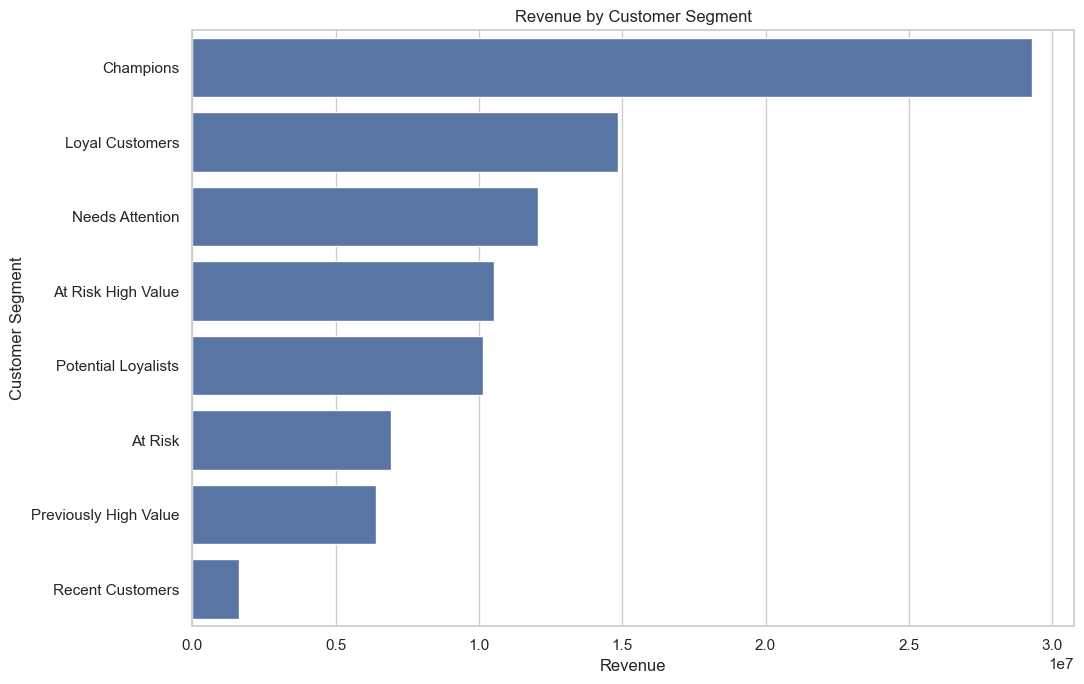

In [32]:
plt.figure(figsize=(11, 7))

sns.barplot(
    data=segment_performance,
    x="Total_Revenue",
    y="Customer_Segment"
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Revenue")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

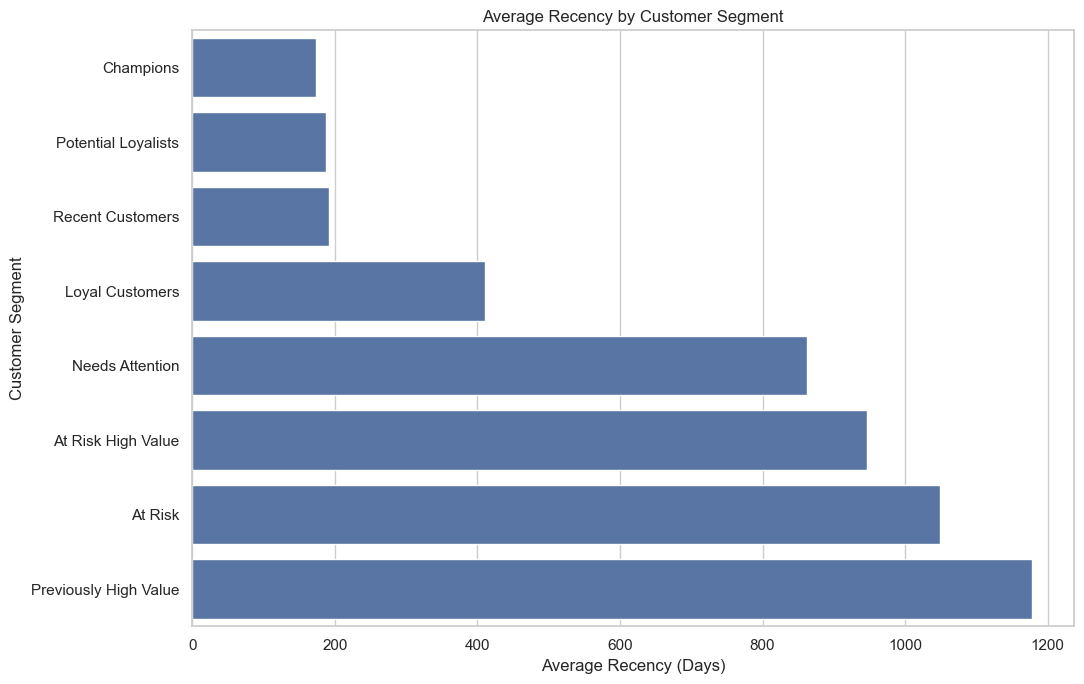

In [33]:
plt.figure(figsize=(11, 7))

sns.barplot(
    data=segment_performance.sort_values(
        "Average_Recency"
    ),
    x="Average_Recency",
    y="Customer_Segment"
)

plt.title("Average Recency by Customer Segment")
plt.xlabel("Average Recency (Days)")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

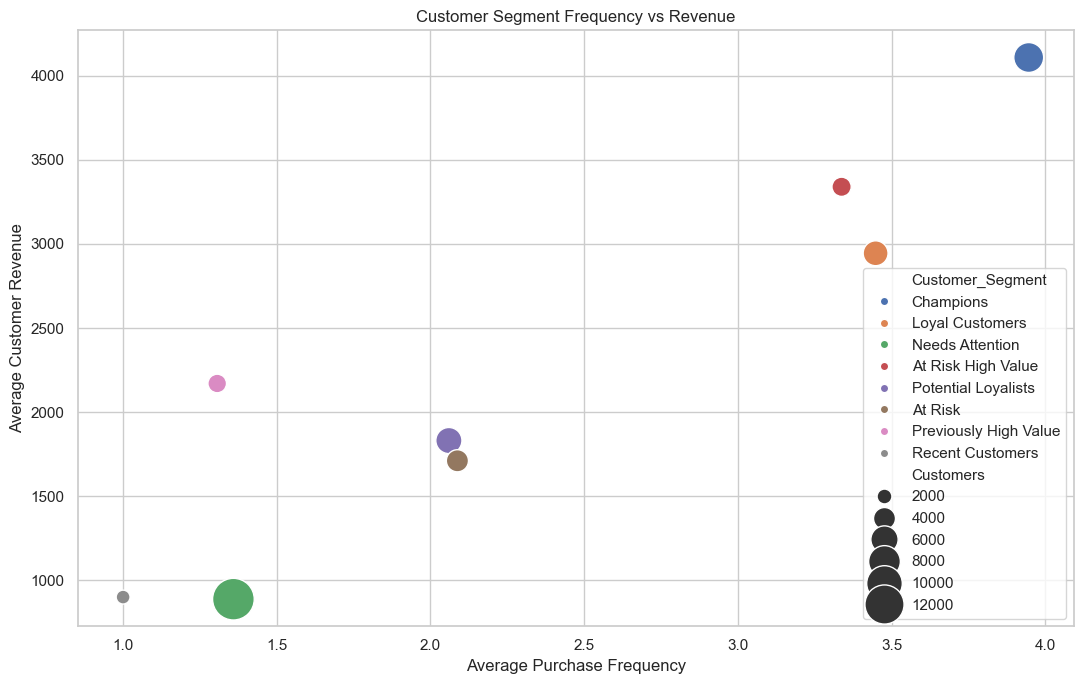

In [34]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=segment_performance,
    x="Average_Frequency",
    y="Average_Revenue",
    size="Customers",
    hue="Customer_Segment",
    sizes=(100, 900)
)

plt.title("Customer Segment Frequency vs Revenue")
plt.xlabel("Average Purchase Frequency")
plt.ylabel("Average Customer Revenue")

plt.tight_layout()
plt.show()

## 11. Top Customers

Customers are ranked by total monetary value and purchase frequency to identify the highest-value customers.

In [35]:
top_customers_revenue = (
    rfm
    .sort_values(
        "Monetary",
        ascending=False
    )
    .head(20)
)

top_customers_revenue[
    [
        "CustomerID",
        "Recency",
        "Frequency",
        "Monetary",
        "Customer_Segment"
    ]
]

,CustomerID,Recency,Frequency,Monetary,Customer_Segment
20573,CUST023748,54,10,15215.79,Champions
8298,CUST009614,165,9,12160.96,Champions
29589,CUST034178,45,6,11418.88,Champions
981,CUST001153,303,9,11282.96,Champions
4215,CUST004883,86,5,11214.44,Champions
680,CUST000787,111,7,10962.32,Champions
13544,CUST015677,15,5,10956.10,Champions
36956,CUST042689,890,8,10726.80,At Risk High Value
13164,CUST015231,82,6,10638.79,Champions
28815,CUST033270,287,5,10593.41,Champions


In [36]:
top_customers_frequency = (
    rfm
    .sort_values(
        "Frequency",
        ascending=False
    )
    .head(20)
)

top_customers_frequency[
    [
        "CustomerID",
        "Recency",
        "Frequency",
        "Monetary",
        "Customer_Segment"
    ]
]

,CustomerID,Recency,Frequency,Monetary,Customer_Segment
32128,CUST037103,18,10,7467.53,Champions
20573,CUST023748,54,10,15215.79,Champions
29677,CUST034288,152,9,7391.20,Champions
42144,CUST048737,373,9,10125.53,Champions
27150,CUST031337,405,9,5292.59,Loyal Customers
37169,CUST042938,273,9,8237.88,Champions
4893,CUST005654,49,9,6698.44,Champions
31800,CUST036736,108,9,5713.40,Champions
10913,CUST012611,191,9,5704.04,Champions
25950,CUST029942,59,9,9969.90,Champions


In [37]:
customer_behavior = (
    df.groupby("CustomerID")
      .agg(
          Orders=("OrderID", "nunique"),
          Revenue=("TotalAmount", "sum"),
          Units=("Quantity", "sum"),
          Categories=("Category", "nunique"),
          Products=("ProductID", "nunique"),
          Brands=("Brand", "nunique")
      )
      .reset_index()
)

customer_behavior.head()

,CustomerID,Orders,Revenue,Units,Categories,Products,Brands
0,CUST000001,1,446.48,1,1,1,1
1,CUST000002,3,1389.93,9,2,3,2
2,CUST000003,1,1116.91,5,1,1,1
3,CUST000004,3,2660.06,7,2,3,3
4,CUST000005,1,1089.56,4,1,1,1


In [38]:
customer_behavior[
    [
        "Orders",
        "Revenue",
        "Units",
        "Categories",
        "Products",
        "Brands"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Orders,43233.0,2.313048,1.257115,1.00,1.00,2.00,3.00,10.00
Revenue,43233.0,2123.971224,1594.379364,6.19,876.19,1805.41,2992.43,15215.79
Units,43233.0,6.942382,4.347894,1.00,4.00,6.00,9.00,35.00
Categories,43233.0,1.970139,0.943005,1.00,1.00,2.00,3.00,6.00
Products,43233.0,2.270048,1.217378,1.00,1.00,2.00,3.00,10.00
Brands,43233.0,2.097379,1.061315,1.00,1.00,2.00,3.00,8.00


In [39]:
category_diversity = (
    customer_behavior["Categories"]
    .value_counts()
    .sort_index()
    .reset_index()
)

category_diversity.columns = [
    "Number_of_Categories",
    "Customers"
]

category_diversity

,Number_of_Categories,Customers
0,1,16024
1,2,15862
2,3,8413
3,4,2507
4,5,402
5,6,25


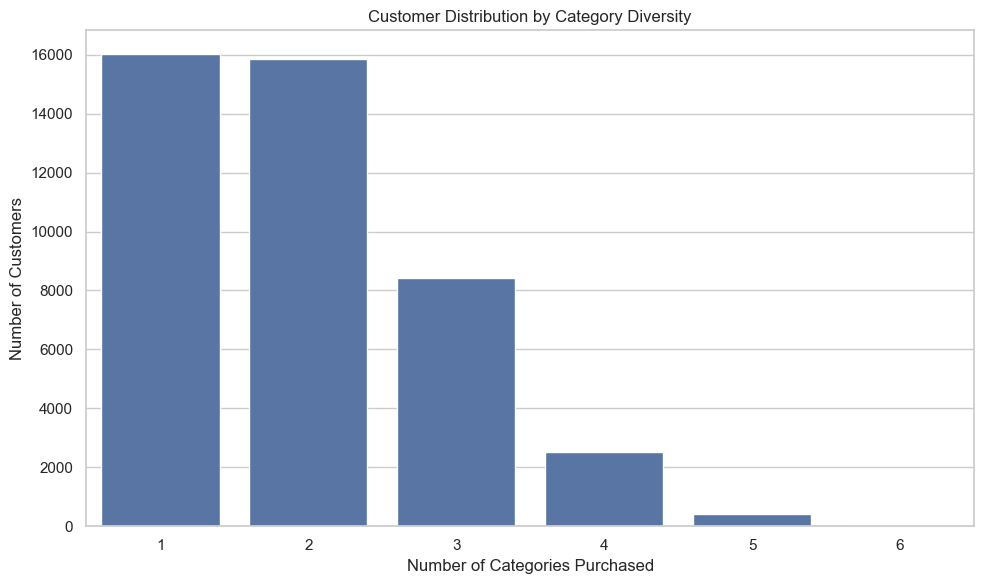

In [40]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_diversity,
    x="Number_of_Categories",
    y="Customers"
)

plt.title("Customer Distribution by Category Diversity")
plt.xlabel("Number of Categories Purchased")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

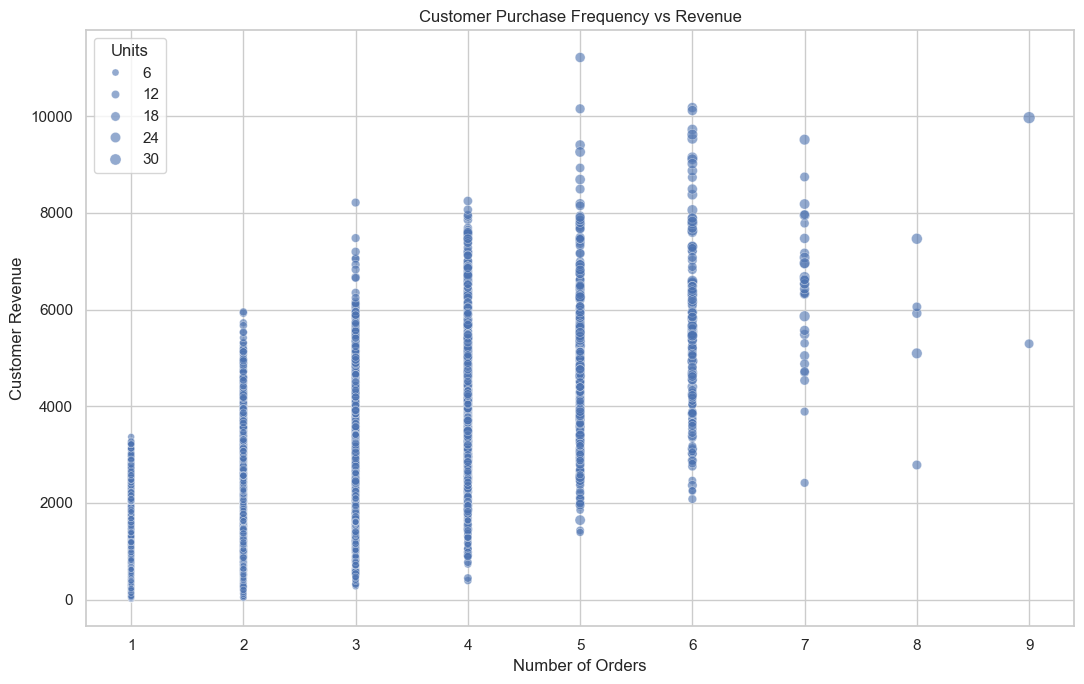

In [41]:
plt.figure(figsize=(11, 7))

sample_customers = customer_behavior.sample(
    min(10000, len(customer_behavior)),
    random_state=42
)

sns.scatterplot(
    data=sample_customers,
    x="Orders",
    y="Revenue",
    size="Units",
    alpha=0.6
)

plt.title("Customer Purchase Frequency vs Revenue")
plt.xlabel("Number of Orders")
plt.ylabel("Customer Revenue")

plt.tight_layout()
plt.show()

In [42]:
customer_frequency_revenue_corr = (
    customer_behavior[
        ["Orders", "Revenue"]
    ]
    .corr()
    .iloc[0, 1]
)

print(
    f"Correlation between order frequency and customer revenue: "
    f"{customer_frequency_revenue_corr:.3f}"
)

Correlation between order frequency and customer revenue: 0.723


In [43]:
customer_category = pd.crosstab(
    df["CustomerID"],
    df["Category"]
)

customer_category.head()

Category,Books,Clothing,Electronics,Home & Kitchen,Sports & Outdoors,Toys & Games
CustomerID,,,,,,
CUST000001,0,0,0,1,0,0
CUST000002,0,0,0,1,0,2
CUST000003,0,0,1,0,0,0
CUST000004,0,0,2,1,0,0
CUST000005,1,0,0,0,0,0


In [44]:
customers_by_category = (
    (customer_category > 0)
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

customers_by_category.columns = [
    "Category",
    "Customers"
]

customers_by_category

,Category,Customers
0,Sports & Outdoors,14305
1,Books,14294
2,Electronics,14235
3,Toys & Games,14159
4,Home & Kitchen,14151
5,Clothing,14031


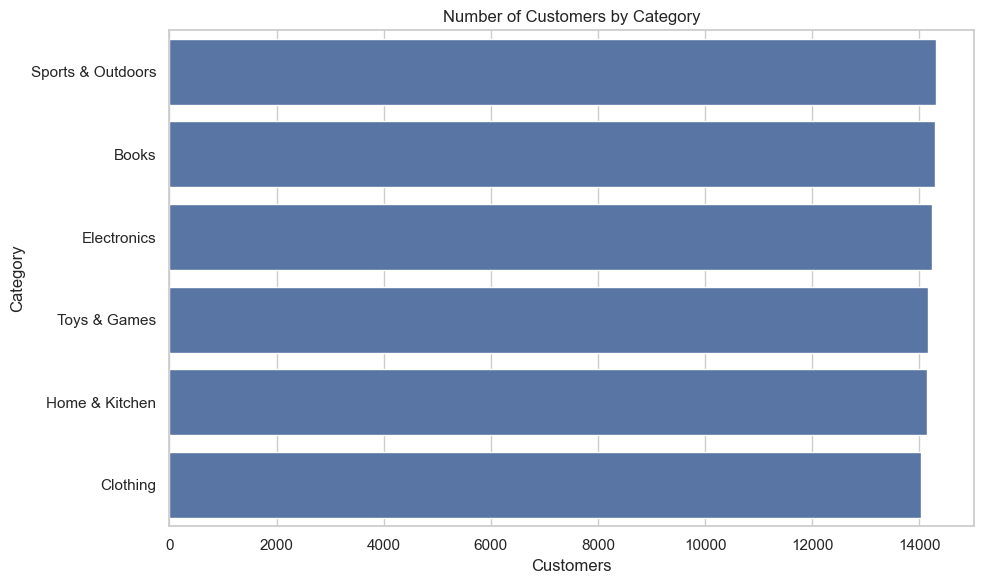

In [45]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=customers_by_category,
    x="Customers",
    y="Category"
)

plt.title("Number of Customers by Category")
plt.xlabel("Customers")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

## 12. Customer Geographic Overview

Customer distribution by country is analyzed at a high level.

Detailed state and city customer analysis is avoided because geographic consistency was identified as a potential data-quality limitation during Notebook 1.

In [46]:
customer_country = (
    df.groupby("Country")
      .agg(
          Customers=("CustomerID", "nunique"),
          Revenue=("TotalAmount", "sum"),
          Orders=("OrderID", "nunique")
      )
      .reset_index()
      .sort_values(
          "Revenue",
          ascending=False
      )
)

customer_country

,Country,Customers,Revenue,Orders
4,United States,37731,64310048.50,70058
2,India,12976,13875839.12,15051
1,Canada,5486,5323757.00,5818
3,United Kingdom,4742,4526896.86,4943
0,Australia,3969,3789106.44,4130


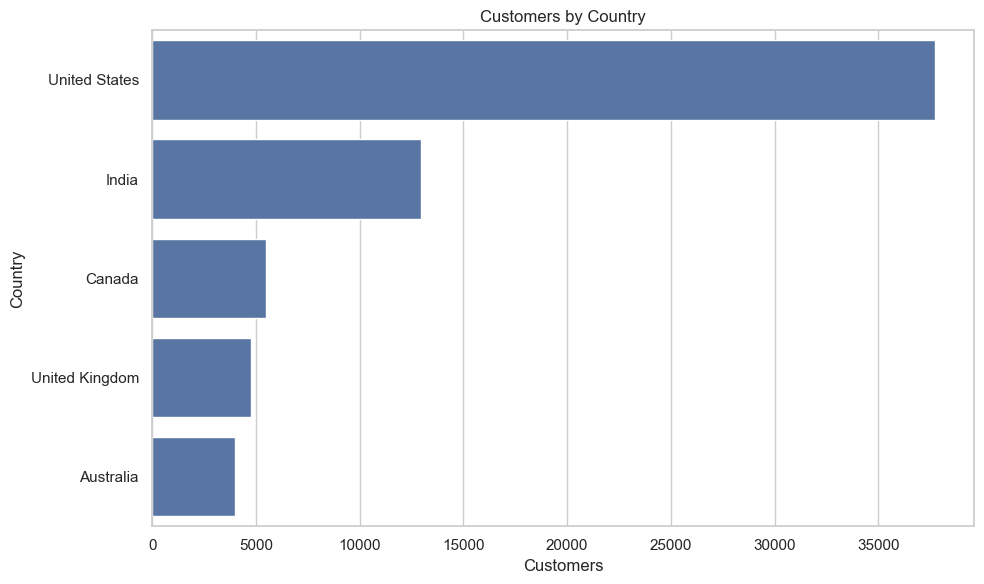

In [47]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=customer_country,
    x="Customers",
    y="Country"
)

plt.title("Customers by Country")
plt.xlabel("Customers")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [48]:
rfm_heatmap = pd.pivot_table(
    rfm,
    values="Monetary",
    index="R_Score",
    columns="F_Score",
    aggfunc="mean"
)

rfm_heatmap

F_Score,1,2,3,4,5
R_Score,,,,,
1,926.527318,1121.414548,1849.472860,2569.176248,3604.407057
2,959.483308,1360.895357,1797.938044,2629.486597,3702.363541
3,938.241033,1361.855266,1804.128998,2656.139453,3774.055093
4,903.104056,1408.395682,1851.416179,2630.377391,3955.514411
5,898.129410,1482.388397,1829.625868,2676.513274,4057.589183


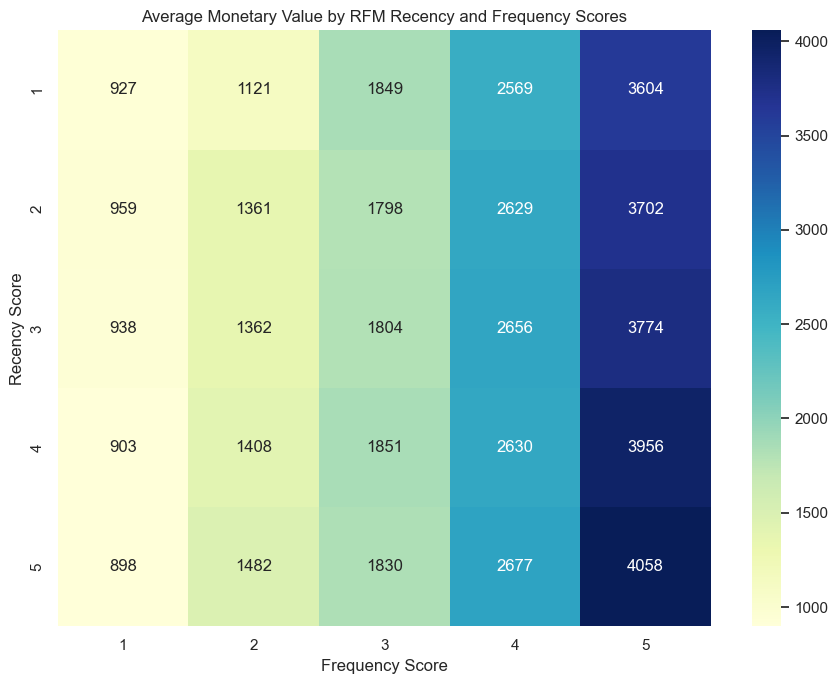

In [49]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    rfm_heatmap,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Average Monetary Value by RFM Recency and Frequency Scores")
plt.xlabel("Frequency Score")
plt.ylabel("Recency Score")

plt.tight_layout()
plt.show()

Q1 — Number of customers

In [50]:
print(
    f"1. Total unique customers: "
    f"{total_customers:,}"
)

1. Total unique customers: 43,233


In [54]:
# Q2 — Repeat customer rate
repeat_customers = (
    customer_summary["Orders"] > 1
).sum()


repeat_customer_rate = (
    repeat_customers /
    total_customers *
    100
)


print(
    f"2. Repeat customer rate: "
    f"{repeat_customer_rate:.2f}%"
)

2. Repeat customer rate: 68.70%


In [55]:
# Q3 — Top customer
top_customer = rfm.loc[
    rfm["Monetary"].idxmax()
]


print(
    f"3. Highest-value customer: "
    f"{top_customer['CustomerID']}"
)


print(
    f"   Revenue: "
    f"${top_customer['Monetary']:,.2f}"
)

3. Highest-value customer: CUST023748
   Revenue: $15,215.79


In [56]:
# Q4 — Most frequent customer
most_frequent_customer = rfm.loc[
    rfm["Frequency"].idxmax()
]


print(
    f"4. Most frequent customer: "
    f"{most_frequent_customer['CustomerID']}"
)


print(
    f"   Orders: "
    f"{most_frequent_customer['Frequency']:,}"
)

4. Most frequent customer: CUST023748
   Orders: 10


In [57]:
# Q5 — Largest customer segment
largest_segment = segment_distribution.iloc[0]


print(
    f"5. Largest customer segment: "
    f"{largest_segment['Customer_Segment']}"
)


print(
    f"   Customers: "
    f"{largest_segment['Customers']:,}"
)

5. Largest customer segment: Needs Attention
   Customers: 13,579


In [58]:
# Q6 — Highest-revenue segment
highest_revenue_segment = segment_performance.iloc[0]


print(
    f"6. Highest-revenue customer segment: "
    f"{highest_revenue_segment['Customer_Segment']}"
)


print(
    f"   Revenue: "
    f"${highest_revenue_segment['Total_Revenue']:,.2f}"
)

6. Highest-revenue customer segment: Champions
   Revenue: $29,298,268.39


In [59]:
# Q7 — Top 10 customer concentration
print(
    f"7. Top 10 customers contribute "
    f"{top_10_customer_share:.2f}% "
    f"of customer revenue."
)

7. Top 10 customers contribute 0.13% of customer revenue.


In [60]:
# Q8 — Most popular category
most_popular_category = customers_by_category.iloc[0]


print(
    f"8. Category purchased by the most customers: "
    f"{most_popular_category['Category']}"
)


print(
    f"   Customers: "
    f"{most_popular_category['Customers']:,}"
)

8. Category purchased by the most customers: Sports & Outdoors
   Customers: 14,305


In [61]:
customer_analysis_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Repeat Customer Rate",
        "Top Customer by Revenue",
        "Top Customer Revenue",
        "Most Frequent Customer",
        "Most Frequent Customer Orders",
        "Largest Customer Segment",
        "Largest Segment Customers",
        "Highest Revenue Segment",
        "Highest Revenue Segment Revenue",
        "Top 10 Customer Revenue Share",
        "Most Popular Category by Customers"
    ],
    "Value": [
        total_customers,
        repeat_customer_rate,
        top_customer["CustomerID"],
        top_customer["Monetary"],
        most_frequent_customer["CustomerID"],
        most_frequent_customer["Frequency"],
        largest_segment["Customer_Segment"],
        largest_segment["Customers"],
        highest_revenue_segment["Customer_Segment"],
        highest_revenue_segment["Total_Revenue"],
        top_10_customer_share,
        most_popular_category["Category"]
    ]
})

customer_analysis_summary

,Metric,Value
0,Total Customers,43233
1,Repeat Customer Rate,68.699836
2,Top Customer by Revenue,CUST023748
3,Top Customer Revenue,15215.79
4,Most Frequent Customer,CUST023748
5,Most Frequent Customer Orders,10
6,Largest Customer Segment,Needs Attention
7,Largest Segment Customers,13579
8,Highest Revenue Segment,Champions
9,Highest Revenue Segment Revenue,29298268.39


In [62]:
output_dir = Path(
    "../Data/Customer_Analytics_Outputs"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

print("Output directory ready.")

Output directory ready.


In [63]:
customer_summary.to_csv(
    output_dir / "customer_summary.csv",
    index=False
)

customer_type_summary.to_csv(
    output_dir / "customer_type_summary.csv",
    index=False
)

customer_type_revenue.to_csv(
    output_dir / "customer_type_revenue.csv",
    index=False
)

customer_concentration.to_csv(
    output_dir / "customer_revenue_concentration.csv",
    index=False
)

rfm.to_csv(
    output_dir / "rfm_customer_segments.csv",
    index=False
)

segment_distribution.to_csv(
    output_dir / "customer_segment_distribution.csv",
    index=False
)

segment_performance.to_csv(
    output_dir / "customer_segment_performance.csv",
    index=False
)

customer_behavior.to_csv(
    output_dir / "customer_behavior.csv",
    index=False
)

customers_by_category.to_csv(
    output_dir / "customers_by_category.csv",
    index=False
)

customer_country.to_csv(
    output_dir / "customer_country_analysis.csv",
    index=False
)

customer_analysis_summary.to_csv(
    output_dir / "customer_analysis_summary.csv",
    index=False
)

print("Customer analysis tables exported successfully.")

Customer analysis tables exported successfully.


# 13. Conclusion

This notebook provided a detailed analysis of customer purchasing behavior.

The analysis examined:

- Customer base size
- Customer revenue distribution
- Purchase frequency
- One-time versus repeat customers
- Customer revenue concentration
- Recency, Frequency, and Monetary value
- RFM customer segmentation
- Segment size and revenue contribution
- Top customers by revenue and purchase frequency
- Customer category diversity
- Customer frequency versus revenue
- Customer-category relationships
- Country-level customer distribution

RFM segmentation provides a structured way to identify customer groups with different purchasing characteristics.

The analysis should be interpreted as behavioral segmentation rather than definitive customer personas. Additional information such as marketing engagement, acquisition source, customer demographics, product cost, and profitability would be required for more comprehensive customer-value analysis.

The RFM and customer-analysis outputs will be used later to support SQL business questions and Power BI customer analytics.